# 線性迴歸 (Linear Regression)

學習目標：
- 了解線性迴歸的原理
- 用 Python 建立第一個預測模型
- 評估模型好不好

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## 1. 準備資料

用運動員的「訓練時數」預測「比賽成績」
這是最直觀的線性迴歸例子

In [2]:
# 建立模擬的運動員資料
np.random.seed(42)
n = 50

training_hours = np.random.uniform(5, 30, n)
performance = 60 + 1.5 * training_hours + np.random.normal(0, 5, n)

df = pd.DataFrame({
    '訓練時數': training_hours,
    '比賽成績': performance
})

print(df.head())
print(f'\n資料筆數：{len(df)}')

        訓練時數        比賽成績
0  14.363503   85.237587
1  28.767858  104.008628
2  23.299849   94.371531
3  19.966462   88.444175
4   8.900466   65.958089

資料筆數：50


## 2. 視覺化資料分布

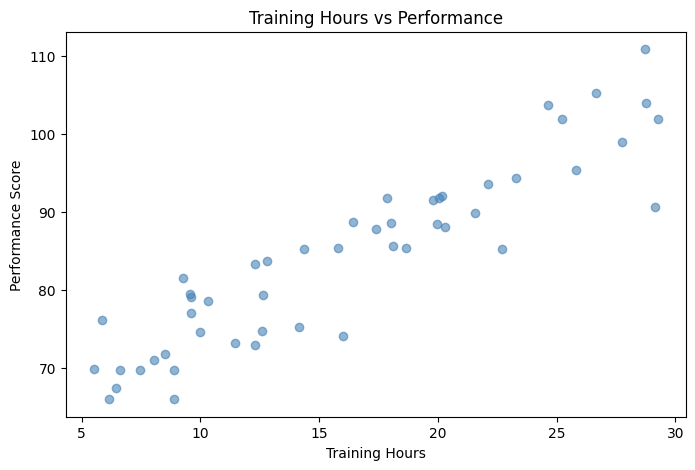

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df['訓練時數'], df['比賽成績'],
            color='steelblue', alpha=0.6)
plt.xlabel('Training Hours')
plt.ylabel('Performance Score')
plt.title('Training Hours vs Performance')
plt.show()

## 3. 建立線性迴歸模型

In [4]:
# 切分訓練集和測試集 (80% 訓練，20% 測試)
X = df[['訓練時數']]
y = df['比賽成績']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'訓練集：{len(X_train)} 筆')
print(f'測試集：{len(X_test)} 筆')

訓練集：40 筆
測試集：10 筆


In [5]:
# 訓練模型
model = LinearRegression()
model.fit(X_train, y_train)

print(f'斜率 (coefficient)：{model.coef_[0]:.3f}')
print(f'截距 (intercept)：{model.intercept_:.3f}')
print(f'\n模型公式：成績 = {model.coef_[0]:.2f} × 訓練時數 + {model.intercept_:.2f}')

斜率 (coefficient)：1.445
截距 (intercept)：60.895

模型公式：成績 = 1.44 × 訓練時數 + 60.89


## 4. 評估模型

RMSE（越小越好）：4.462
R²（越接近1越好）：0.782


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38555 (\N{CJK UNIFIED IDEOGRAPH-969B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas

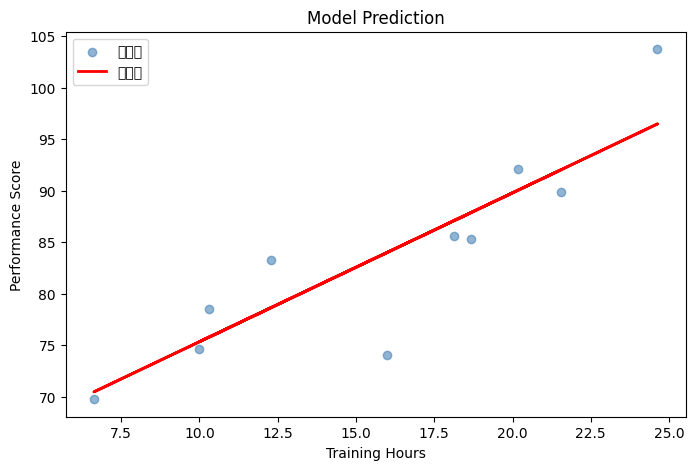

In [6]:
# 預測測試集
y_pred = model.predict(X_test)

# 計算評估指標
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'RMSE（越小越好）：{rmse:.3f}')
print(f'R²（越接近1越好）：{r2:.3f}')

# 畫出預測線
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='steelblue',
            label='實際值', alpha=0.6)
plt.plot(X_test, y_pred, color='red',
         linewidth=2, label='預測線')
plt.xlabel('Training Hours')
plt.ylabel('Performance Score')
plt.title('Model Prediction')
plt.legend()
plt.show()

## 5. 我的學習筆記

1. 這個主題在做什麼：
   用「訓練時數」這個特徵，建立一條直線來預測「比賽成績」。
   模型學習的就是這條直線的斜率和截距。

2. 關鍵概念：
   - RMSE：預測值跟真實值平均差多少分
   - R²：模型能解釋多少%的成績變化（越接近1越好）
   - 訓練集/測試集分割：用沒看過的資料評估模型才公平

3. 我覺得最難理解的地方：
   （填入你自己的想法）

4. 這個跟我研究的連結：
   這個模型的概念可以延伸到深度學習：
   深度學習就是很多層的「非線性迴歸」疊在一起，
   預測運動員表現的原理是一樣的，只是模型更複雜。